# 02 Indicator Strategies

Evaluate MACD, RSI, SMA crossover, Bollinger Bands, and Momentum rules with a one-day execution lag and explicit transaction costs.

In [1]:
# Project configuration and reproducibility
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    SEED,
    START_DATE,
    END_DATE,
    TRAIN_END_DATE,
    TICKERS,
    CACHE_DIR,
    RESULTS_DIR,
    CHARTS_DIR,
    TRANSACTION_COST,
    set_global_seed,
    ensure_directories,
)

set_global_seed(SEED)
ensure_directories()
print(f"Configured {len(TICKERS)} US/UK indices from {START_DATE} to {END_DATE} with seed={SEED}.")


Configured 7 US/UK indices from 2013-01-01 to 2023-01-01 with seed=42.


## Build execution note

These notebooks were rebuilt from scratch with clean metadata and empty outputs. Live data execution was not completed during repository build because the sandbox could not resolve Yahoo Finance hosts. After installing `requirements.txt` in a normal networked environment, run the notebooks in order from `01_data.ipynb` to `04_combined_model.ipynb`.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.backtest import apply_backtest, save_results_table, summarize_backtest
from src.signals import indicator_signals

plt.style.use("seaborn-v0_8-whitegrid")


In [3]:
def load_cached_data() -> dict[str, pd.DataFrame]:
    frames = {}
    for name, symbol in TICKERS.items():
        cache_path = CACHE_DIR / (symbol.replace("^", "").replace(".", "_") + ".csv")
        if not cache_path.exists():
            # Match the sanitization used in 01_data.ipynb.
            import re
            cache_path = CACHE_DIR / (re.sub(r"[^A-Za-z0-9]+", "_", symbol).strip("_") + ".csv")
        if cache_path.exists():
            frames[name] = pd.read_csv(cache_path, index_col=0, parse_dates=True)
    if not frames:
        raise FileNotFoundError("No cached data found. Run notebooks/01_data.ipynb first.")
    return frames

price_data = load_cached_data()
print(f"Loaded {len(price_data)} cached US/UK indices.")


Loaded 7 cached US/UK indices.


In [4]:
rows = []
backtests = {}

for index_name, frame in price_data.items():
    for strategy_name, signal in indicator_signals(frame).items():
        result = apply_backtest(frame, signal, cost=TRANSACTION_COST)
        rows.append(summarize_backtest(index_name, strategy_name, result))
        backtests[(index_name, strategy_name)] = result

indicator_results = save_results_table(rows, RESULTS_DIR / "indicator_results.csv")
indicator_results.sort_values("Sharpe", ascending=False).head(15)


,index,strategy,gross_return,net_return,ann_vol,Sharpe,max_drawdown,n_trades,vs_buy_and_hold
14,NASDAQ Composite,Momentum,1.444732,0.985628,0.120375,0.570511,-0.199312,208,-1.377356
5,Dow Jones Industrial Average,MACD,1.077272,0.707543,0.096850,0.553118,-0.171922,196,-0.763818
33,Cboe Volatility Index,Bollinger Bands,3.937562,3.854333,0.288474,0.548317,-0.304662,17,3.378175
3,S&P 500,Bollinger Bands,1.458952,1.336690,0.155199,0.547523,-0.286196,51,-0.288753
6,Dow Jones Industrial Average,RSI,1.058835,1.010011,0.148160,0.471769,-0.314850,24,-0.461350
10,NASDAQ Composite,MACD,1.126195,0.751257,0.119263,0.470390,-0.240622,194,-1.611727
18,Russell 2000,Bollinger Bands,1.452006,1.306904,0.187048,0.447427,-0.415614,61,0.290406
8,Dow Jones Industrial Average,Bollinger Bands,1.072440,0.965461,0.153946,0.439461,-0.370862,53,-0.505900
13,NASDAQ Composite,Bollinger Bands,1.284567,1.184041,0.180848,0.432467,-0.371563,45,-1.178943
12,NASDAQ Composite,SMA crossover,0.741847,0.656897,0.140392,0.360098,-0.310657,50,-1.706087


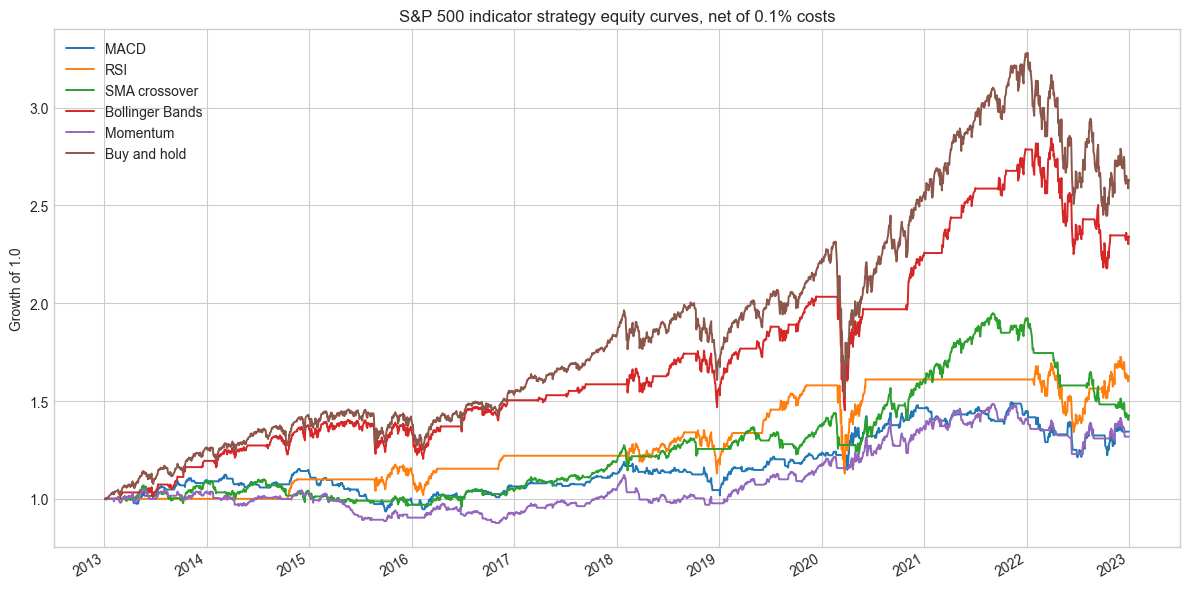

In [5]:
sp500_curves = []
for (index_name, strategy_name), result in backtests.items():
    if index_name == "S&P 500":
        curve = np.exp(result["net_strategy_return"].cumsum())
        curve.name = strategy_name
        sp500_curves.append(curve)

if sp500_curves:
    equity = pd.concat(sp500_curves, axis=1)
    buy_hold = np.exp(backtests[("S&P 500", "MACD")]["buy_and_hold_return"].cumsum())
    buy_hold.name = "Buy and hold"
    equity = equity.join(buy_hold)

    fig, ax = plt.subplots(figsize=(12, 6))
    equity.plot(ax=ax, linewidth=1.4)
    ax.set_title("S&P 500 indicator strategy equity curves, net of 0.1% costs")
    ax.set_ylabel("Growth of 1.0")
    ax.set_xlabel("")
    fig.tight_layout()
    fig.savefig(CHARTS_DIR / "indicator_equity_curves_sp500.png", dpi=160)
    plt.show()


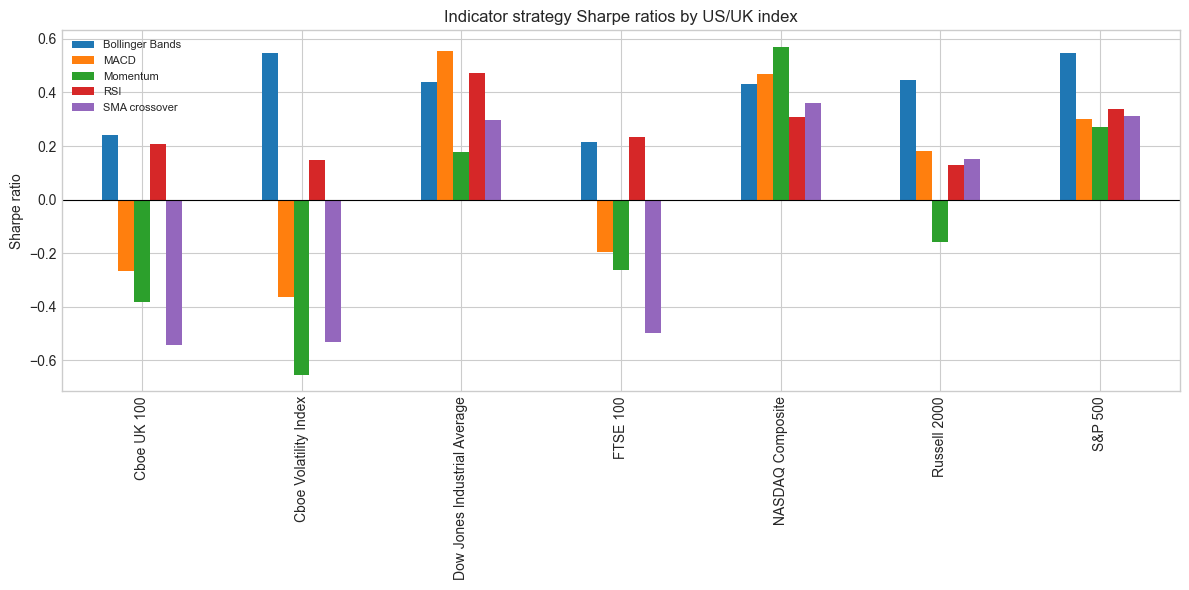

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_data = indicator_results.pivot(index="index", columns="strategy", values="Sharpe")
plot_data.plot(kind="bar", ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Indicator strategy Sharpe ratios by US/UK index")
ax.set_ylabel("Sharpe ratio")
ax.set_xlabel("")
ax.legend(loc="best", fontsize=8)
fig.tight_layout()
fig.savefig(CHARTS_DIR / "strategy_sharpe_by_index.png", dpi=160)
plt.show()
